# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** Tim Kung 
**SFU ID:** 301420651
**Date:** June 24

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
# %pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [3]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [4]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [5]:
# Missing values
df_ab.isnull().sum()


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


In [6]:
mm_scaler = MinMaxScaler()
std_scaler = StandardScaler()
rbst_scaler = RobustScaler()

df_ab["avg_whiteboard_session_duration_min_scaled"] = mm_scaler.fit_transform(df_ab[["avg_whiteboard_session_duration_min"]])
df_ab["avg_whiteboard_session_duration_min_scaled"].describe()

count    2000.000000
mean        0.225668
std         0.136895
min         0.000000
25%         0.130538
50%         0.197673
75%         0.289436
max         1.000000
Name: avg_whiteboard_session_duration_min_scaled, dtype: float64

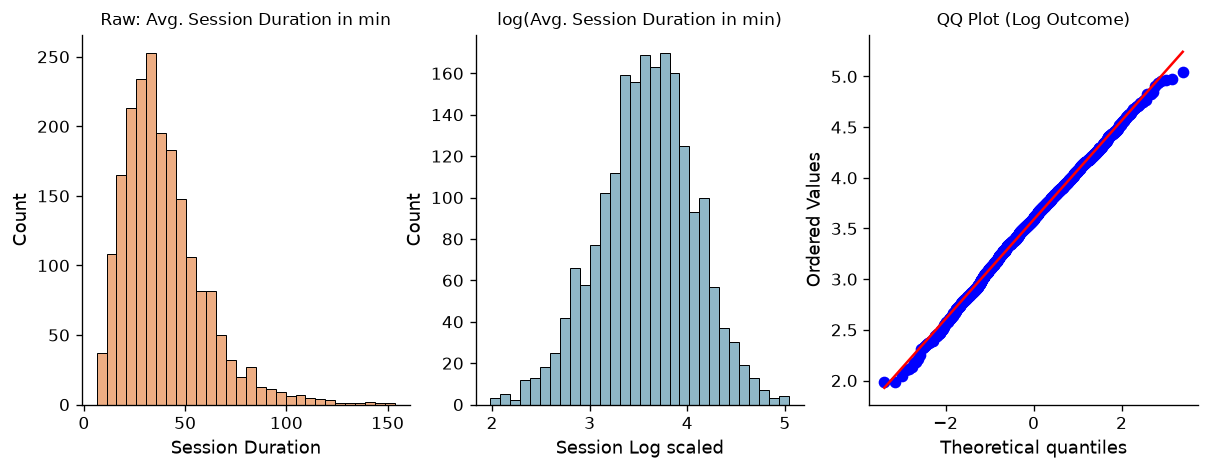

<Figure size 768x576 with 0 Axes>

In [7]:
# BEGIN
from scipy.stats import skew

#     Load target outcome variable
from scipy.stats import skew
df_ab["avg_whiteboard_session_duration_min_log_scaled"] = np.log1p(df_ab["avg_whiteboard_session_duration_min"])

#     // 1. Normality & Transformation Visualizations
#     Initialize three-panel visual layout
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

#  Transform outcome variable using natural logarithm
#     Draw histogram of raw outcome distribution
sns.histplot(df_ab["avg_whiteboard_session_duration_min"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Raw: Avg. Session Duration in min", fontsize=10)
axes[0].set_xlabel("Session Duration")

#     Draw histogram of log-transformed outcome distribution
sns.histplot(df_ab["avg_whiteboard_session_duration_min_log_scaled"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("log(Avg. Session Duration in min)", fontsize=10)
axes[1].set_xlabel("Session Log scaled")

# #     Draw Q-Q plot comparing log-transformed distribution to a normal distribution
"""
osm = An array of theoretical quantiles (Order Statistic Medians) calculated for our theoretical distribution
osr = ordered (sorted) sample data responses

slope = The slope of the least-squares best-fit line
intercept = The intercept of the best-fit line
r = The square root of the coefficient of determination (R²). It represents the strength of the linear fit
"""
(osm, osr), (slope, intercept, r) = stats.probplot(df_ab["avg_whiteboard_session_duration_min_log_scaled"], dist="norm", plot=plt)

# Customize titles with matplotlib
plt.title("QQ Plot (Log Outcome)", fontsize=10)
plt.show()

#     Render visualizations
sns.despine()
plt.tight_layout()
plt.show()
    
#     // 2. Statistical Diagnostics
#     Compute and output skewness for both raw and log-transformed distributions
raw_skew = skew(df_ab["avg_whiteboard_session_duration_min"], bias=False) # => 1.3767967385922617
log_skew = skew(df_ab["avg_whiteboard_session_duration_min_log_scaled"], bias=False) # => -0.16285190262831545

# END

In [8]:
#     Compute and output skewness for both raw and log-transformed distributions
print(f"Raw Skew: {raw_skew}")
print(f"Log Skew: {log_skew}")

Raw Skew: 1.3767967385922617
Log Skew: -0.16285190262831542


**✏️ Your interpretation (A1.1):**
*Is the log-transformed outcome more normally distributed? How does the Q-Q plot support your conclusion? Will you use the raw or log outcome in your model?*

**My Answer:**<br>
The log-transformed outcome is more normally distributed. I observe a closer normalized fit in comparison, with very minor curves at the tail ends. This is probably due to a few extreme values that causes the skew, but unlikely to cause major issues if we were to continue using the log outcome.

#### A1.2 — Examine the confounders

Pearson r (whiteboard_actions_per_sessions vs log_duration): 0.9136

Descriptive Stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


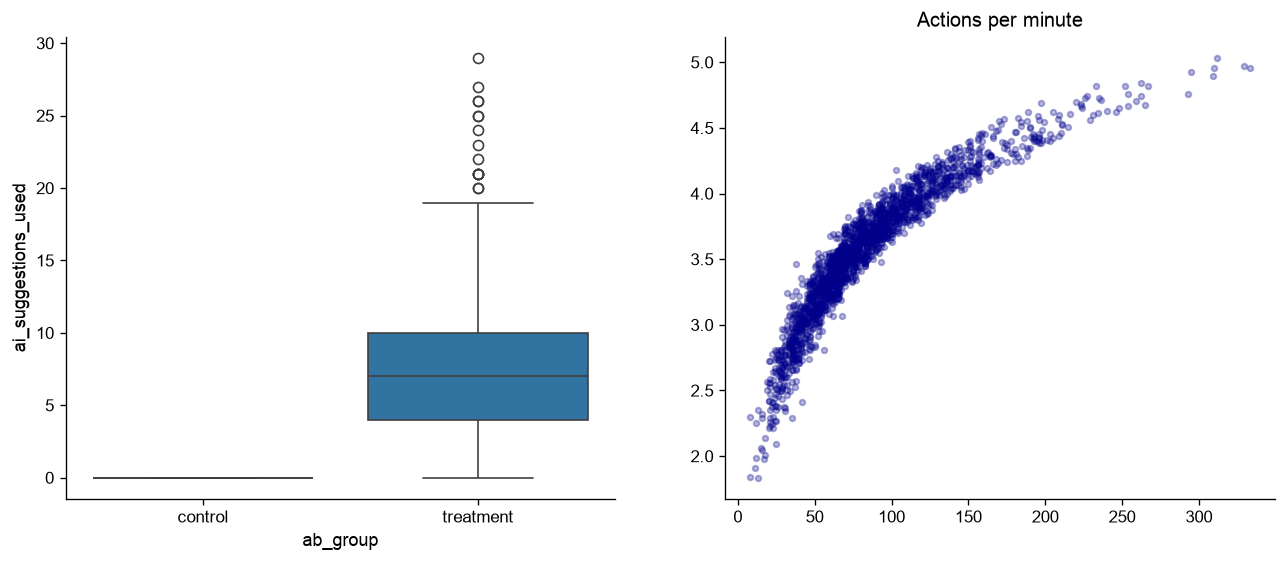

In [9]:
# // Define the analytical pipeline
# BEGIN
#     Load AB testing dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.set(style="ticks")
sns.set_style("darkgrid")
#     // 1. Visual Exploratory Data Analysis
#     Initialize side-by-side visualization layouts
    
#     Draw boxplot comparison of AI suggestion usage across experimental groups
sns.boxplot(data=df_ab, x="ab_group", y="ai_suggestions_used", ax=axes[0])

#     Draw scatter plot comparing whiteboard activity density against session durations
log_duration = np.log(df_ab["avg_whiteboard_session_duration_min"])
axes[1].scatter(df_ab["whiteboard_actions_per_session"], log_duration, color="darkblue", alpha=0.3, s=12)
axes[1].set_title("Actions per minute")

#     Optimize layout and display visualizations

#     // 2. Statistical Analysis
#     Calculate and print the correlation between whiteboard activity and session duration
corr_actions = df_ab["whiteboard_actions_per_session"].corr(log_duration)
print(f"Pearson r (whiteboard_actions_per_sessions vs log_duration): {corr_actions:.4f}\n")

#     Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
print("Descriptive Stats for ai_suggestions_used by group:")
print(df_ab.groupby("ab_group")["ai_suggestions_used"].describe().round(2))

# END

**✏️ Your interpretation (A1.2):**

*What do you notice about `ai_suggestions_used` across the two groups? What does the correlation between `whiteboard_actions_per_session` and the outcome suggest? Why should neither be included in your model?*

I observe that in ai_suggestion_used, control is exactly 0 with no variance (due to the nature of the experiment), while treatment averages 7.33, making this variable a good proxy for ab_group and a post-treatment mediator. Moreover, I observe a high correlation between whiteboard_actions_per_session and the outcome (with a Pearson r = 0.91). This shows that session duration and the in-session count move together (longer sessions, more actions). Both these variables are measured as a result of the treatment being applied; and given their correlation, the model may predict their relationship instead of considering them proxies, and introduce potential bias into the model.



#### A1.3 — Predictor distributions and relationships with outcome

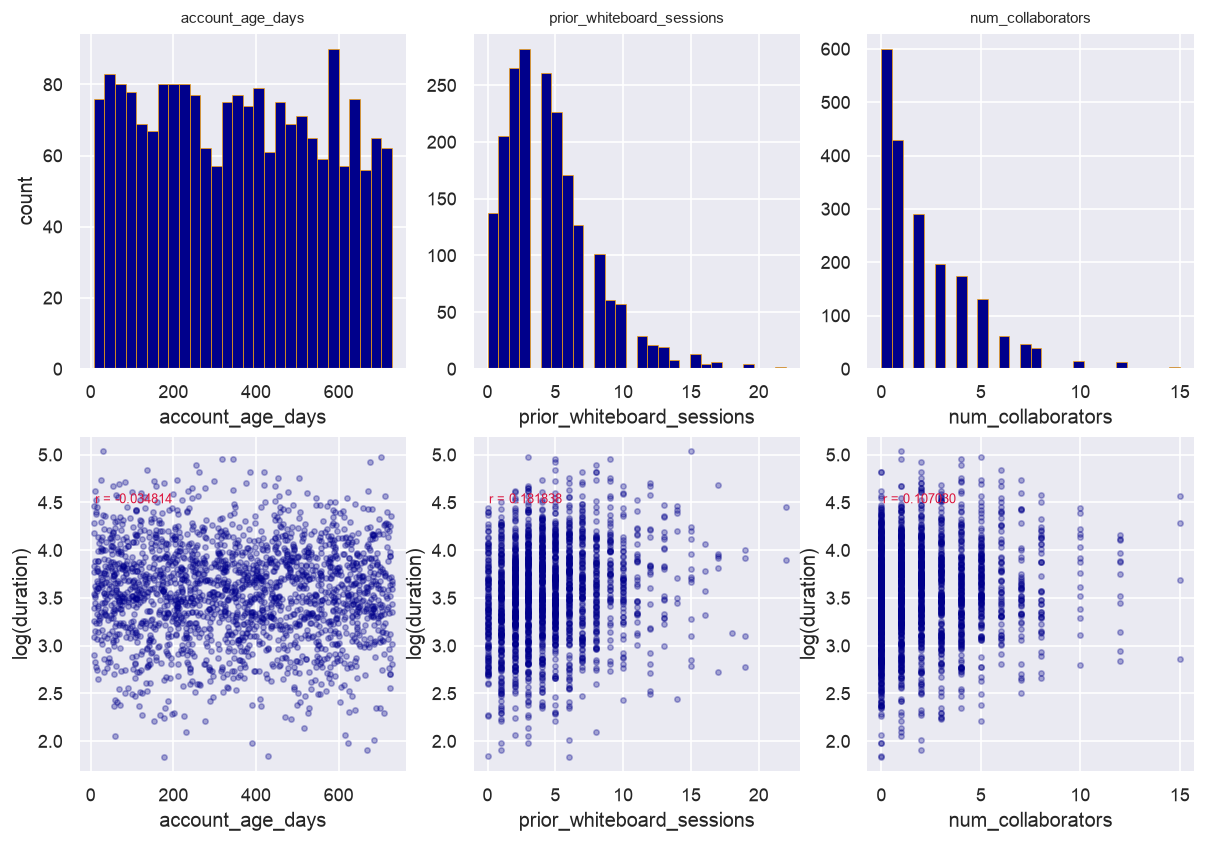

In [10]:
# BEGIN
#     Define list of numerical predictor variables
#     Compute log-transformed outcome variable
num_predict = [
    "account_age_days",
    "prior_whiteboard_sessions",
    "num_collaborators"
]

n = len(num_predict)

fix, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle("Two of the numerical predictors: distributions (top) and vs log(duration) (bottom)",
             fontsize=13, y=1.01)

#     Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)
#     FOR each predictor variable:
for j, col in enumerate(num_predict):
#         Top row: Univariate Analysis
#         Draw histogram to show distribution of the predictor
    axes[0, j].hist(df_ab[col], bins=28, color="darkblue", edgecolor="orange", lw=0.4)
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel("count" if j == 0 else "")

#         // Bottom row: Bivariate Analysis
#         Draw scatter plot comparing predictor against log-transformed outcome
#         Calculate correlation coefficient between predictor and log-transformed outcome
#         Annotate plot with correlation coefficient
    r = df_ab[col].corr(log_duration)
    axes[1, j].scatter(df_ab[col], log_duration, color="darkblue", alpha=0.3, s=10)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel("log(duration)")
    axes[1, j].annotate(f"r = {r:2f}", xy=(0.05, 0.8), xycoords="axes fraction", fontsize=8, color="crimson")

#     END FOR

#     Add global title and render layout
# END

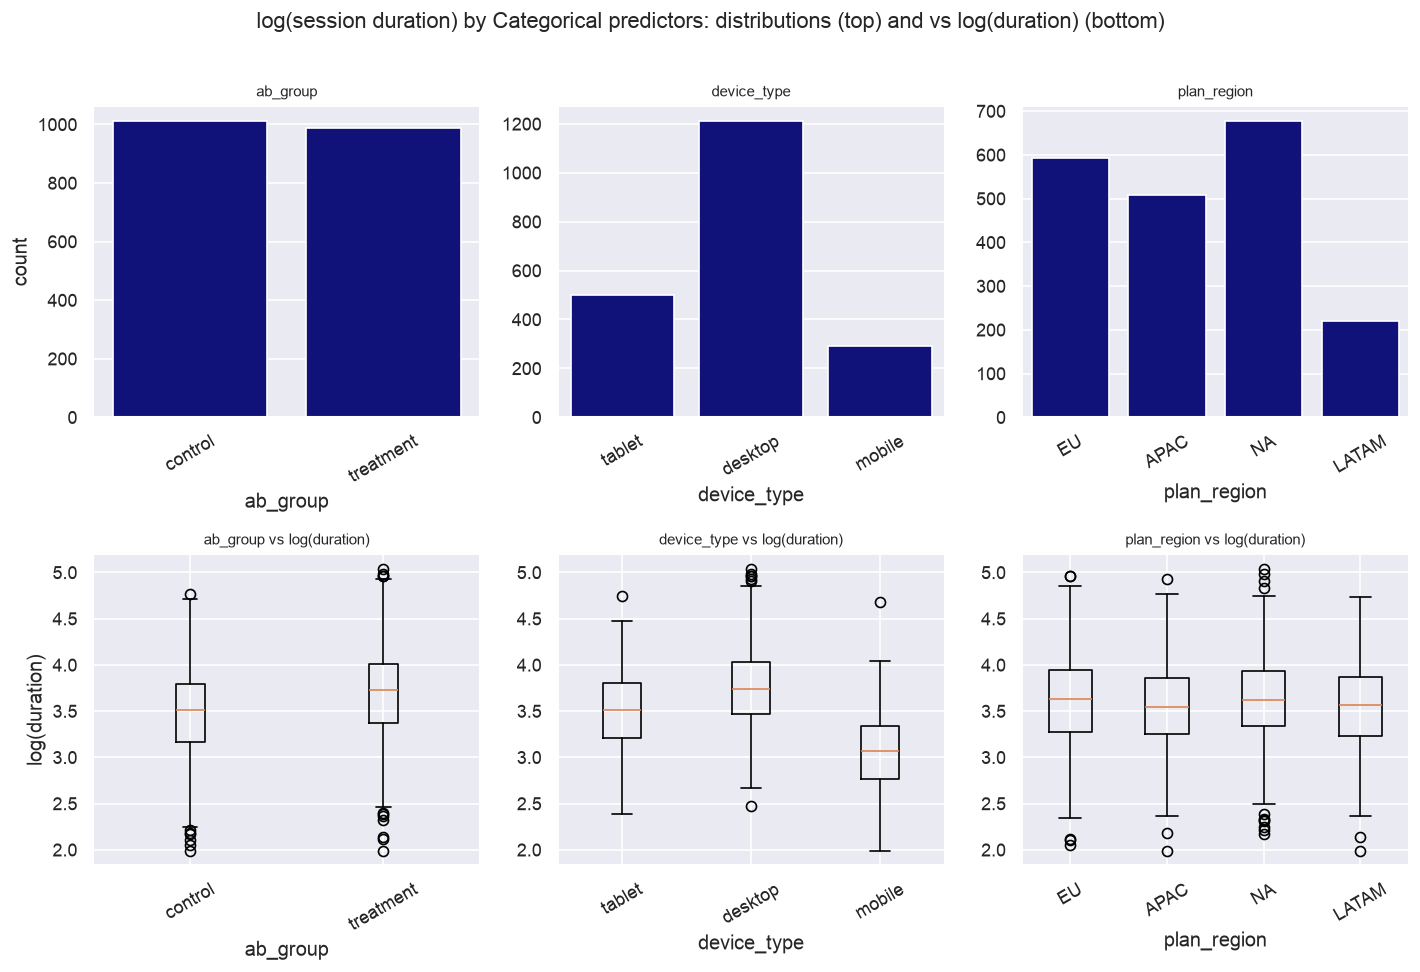

In [24]:
# BEGIN
#     Define list of categorical predictor variables
cat_predict = [
    "ab_group",
    "device_type",
    "plan_region"
]
#     Initialize visual grid layout (2 rows by N columns, where N is the number of categories)
n = len(cat_predict)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle("log(session duration) by Categorical predictors: distributions (top) and vs log(duration) (bottom)",
             fontsize=13, y=1.01)

log_duration = np.log1p(df_ab["avg_whiteboard_session_duration_min"])

#     FOR each categorical variable:
for j, col in enumerate(cat_predict):
    #         Retrieve unique category levels
    levels = df_ab[col].unique()

    #         Top row: count of each category level
    sns.countplot(data=df_ab, x=col, ax=axes[0, j], color="darkblue")
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel("count" if j == 0 else "")
    axes[0, j].tick_params(axis='x', rotation=30)

    #         Group log-transformed outcome values by category levels
    #         Draw boxplots of log-transformed outcome grouped by category level
    grouped = [log_duration[df_ab[col] == lvl].values for lvl in levels]
    
    axes[1, j].boxplot(grouped, tick_labels=levels)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel("log(duration)" if j == 0 else "")
    axes[1, j].set_title(f"{col} vs log(duration)", fontsize=9)
    axes[1, j].tick_params(axis="x", rotation=30)

#     END FOR

#     Render layout
plt.tight_layout()
plt.show()
# END

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*
- Treatment => Users using AI suggestions for work; Control => Users not using AI suggestions work
- Treatment users spend a longer duration working (whiteboard sessions) compared to their non-AI counterparts
- Workers on desktop have longer sessions compared to tablet and mobile users. This makes sense as desktop capabilities are more expanded and suitable for work.
- EU & NA generally have longer work sessions compared to Asia Pacific/Asia Central (APAC) and Latin America (LATAM). This might be an interesting predictor to see if there is cultural influence (i.e., does AI benefit certain culture more than others? Influence of native langauge of AI model?)


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
# BEGIN

# 1. Encode Categorical Variables
# Convert experimental group ('ab_group') into a binary integer indicator
df_ab['ab_group_enc'] = (df_ab['ab_group'] == 'treatment').astype(int)

# Generate dummy indicators (one-hot encoding) for device types
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device').astype(int)

# Generate dummy indicators (one-hot encoding) for regions
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region').astype(int)

# 2. Perform Optional Transformations
# Log-transform right-skewed count predictors using log(x + 1) to avoid log(0)
df_ab['log_prior_whiteboard_sessions'] = np.log1p(df_ab['prior_whiteboard_sessions'])
df_ab['log_num_collaborators'] = np.log1p(df_ab['num_collaborators'])
df_ab['log_templates_used'] = np.log1p(df_ab['templates_used'])

# 3. Assemble Modeling Dataset
# Merge numerical characteristics, binary group indicator, and dummy indicators into X
# Exclude post-treatment variables: ai_suggestions_used, whiteboard_actions_per_session
num_features = df_ab[['account_age_days',
                       'feature_tour_completed',
                       'log_prior_whiteboard_sessions',
                       'log_num_collaborators',
                       'log_templates_used']]

X = pd.concat([num_features, df_ab[['ab_group_enc']], device_dummies, region_dummies], axis=1)

# Set target vector y as the log-transformed outcome variable
y = df_ab['avg_whiteboard_session_duration_min_log_scaled']

# 4. Quality Control
print(f"Any NaN in X: {X.isnull().any().any()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
X.head(10)

# END

**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*


### A3 — OLS Regression


In [ ]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X.astype(float))
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


#### A3.1 — Interpret the model

In [ ]:
# BEGIN
# Input: model_ols — trained OLS regression model
# Input: df_ab    — experimental dataframe

# 1. Evaluate Model Fit
print(f"R-squared: {model_ols.rsquared:.4f}")
print(f"  The model explains {model_ols.rsquared * 100:.1f}% of variance in log(session duration).\n")

# 2. Analyze Treatment Effect
ab_coef = model_ols.params['ab_group_enc']
ab_pval = model_ols.pvalues['ab_group_enc']

# Convert log-space coefficient back to physical time (minutes)
# In a log1p-linear model, exp(coef) - 1 gives the proportional change in the original scale.
pct_change       = (np.exp(ab_coef) - 1) * 100
mean_duration    = df_ab['avg_whiteboard_session_duration_min'].mean()
effect_min       = mean_duration * (np.exp(ab_coef) - 1)

print("Treatment Effect (AI assistant access, ab_group_enc):")
print(f"  Coefficient (log scale)       : {ab_coef:.4f}")
print(f"  Estimated effect              : +{pct_change:.1f}% session duration")
print(f"  Estimated effect at mean      : +{effect_min:.1f} min  (baseline mean = {mean_duration:.1f} min)")
print(f"  p-value                       : {ab_pval:.4f}  ({'significant' if ab_pval < 0.05 else 'not significant'} at α = 0.05)\n")

# 3. Extract Significant Predictors (p < 0.05)
results = pd.DataFrame({
    'coef'  : model_ols.params,
    'pvalue': model_ols.pvalues
})
sig_predictors = results[results['pvalue'] < 0.05].drop(index='const', errors='ignore')

print("Significant Predictors (p < 0.05):")
for var, row in sig_predictors.iterrows():
    direction = "↑" if row['coef'] > 0 else "↓"
    print(f"  {direction} {var:40s}  coef = {row['coef']:+.4f},  p = {row['pvalue']:.4f}")
# END

**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*


#### A3.2 — Regression diagnostics

In [ ]:
# Extract predictions and residuals from the fitted model
fitted_vals = model_ols.fittedvalues
residuals   = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Check for uniform variance (homoscedasticity)
axes[0].scatter(fitted_vals, residuals, alpha=0.4, edgecolors="k", linewidths=0.3)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Check for normality of errors
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*
<br>
<br>
**My hypothesis:**
I am testing the interaction between AI assistant access (`ab_group_enc`) and desktop device use (`device_type == "desktop"`). My reasoning is that desktop users have larger screens and precise mouse/keyboard input, which makes it substantially easier to review, iterate on, and act on AI-generated design suggestions compared to mobile or tablet users who are constrained by touch input and smaller viewports. Because desktop affords deeper engagement with complex AI outputs (more complex instructions, suggestions, etc.), so I predict that desktop users in the treatment group will show a larger boost in session duration than mobile or tablet users in the treatment group — i.e., a positive interaction coefficient for `ab_group_enc x is_desktop`.




In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# device_desktop is the reference category (dropped by get_dummies), so we rebuild it directly
is_desktop = (df_ab['device_type'] == 'desktop').astype(int)
df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * is_desktop
interaction_col = df_ab[['ab_x_device_desktop']]

# Step 2: Add the interaction term to your feature matrix and refit OLS
X_interact = pd.concat([X_const, interaction_col], axis=1)
model_interact = sm.OLS(y, X_interact).fit()
print(model_interact.summary())


In [ ]:
# YOUR CODE HERE
# Visualize the interaction: treatment effect on log(session duration), split by desktop vs non-desktop
# Create readable device label for the moderating variable
df_ab['device_group'] = np.where(df_ab['device_type'] == 'desktop', 'Desktop', 'Non-Desktop')

# Compute group means of the log-transformed outcome
interact_means = (
    df_ab.groupby(['ab_group', 'device_group'])['avg_whiteboard_session_duration_min_log_scaled']
    .mean()
    .reset_index()
    .rename(columns={'avg_whiteboard_session_duration_min_log_scaled': 'mean_log_duration'})
)

device_order = ['Desktop', 'Non-Desktop']
group_colors = {'control': '#6a9fb5', 'treatment': ACCENT}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Interaction: AI Assistant Treatment x Device Type on log(Session Duration)', fontsize=13)

# --- Plot 1: Grouped bar chart ---
pivot = (
    interact_means
    .pivot(index='device_group', columns='ab_group', values='mean_log_duration')
    .reindex(device_order)
)
x = np.arange(len(device_order))
width = 0.35
for i, grp in enumerate(['control', 'treatment']):
    axes[0].bar(x + (i - 0.5) * width, pivot[grp], width,
                label=grp.capitalize(), color=group_colors[grp], edgecolor='white', linewidth=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(device_order)
axes[0].set_xlabel('Device Group')
axes[0].set_ylabel('Mean log(Session Duration)')
axes[0].set_title('Grouped Bar Chart')
axes[0].legend(title='Group')

# --- Plot 2: Interaction line plot ---
for grp, color in group_colors.items():
    subset = interact_means[interact_means['ab_group'] == grp].set_index('device_group').reindex(device_order)
    axes[1].plot(device_order, subset['mean_log_duration'],
                 marker='o', label=grp.capitalize(), color=color, linewidth=2.5, markersize=9)

axes[1].set_xlabel('Device Group')
axes[1].set_ylabel('Mean log(Session Duration)')
axes[1].set_title('Interaction Line Plot\n(Non-parallel lines => interaction present)')
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()

# Numeric summary of the interaction
print("\nMean log(session duration) by group x device:")
print(pivot.round(4).to_string())
treatment_gap_desktop     = pivot.loc['Desktop',     'treatment'] - pivot.loc['Desktop',     'control']
treatment_gap_nondesktop  = pivot.loc['Non-Desktop', 'treatment'] - pivot.loc['Non-Desktop', 'control']
print(f"\nTreatment effect on Desktop     : +{treatment_gap_desktop:.4f} log-units")
print(f"Treatment effect on Non-Desktop : +{treatment_gap_nondesktop:.4f} log-units")
print(f"Difference-in-differences       : {treatment_gap_desktop - treatment_gap_nondesktop:+.4f} log-units")

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*
<br>
<br>
My hypothesis was supported. Desktop users see the most benefit from the AI assistant. Therefore, the data implies that Phigma should roll out the feature for Desktop users first then follow-up with non-desktop users after.


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [ ]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


In [ ]:
df_sub.describe(include='all').round(2)


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] > 0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d'],
    0.0
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal):
df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1': 1, 'tier_2': 2, 'tier_3': 3})

# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
num_cols = df_sub[['num_sessions_30d', 'total_time_min_30d', 'projects_created_30d',
                    'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d',
                    'used_premium_feature_preview', 'ai_assistant_sessions_30d',
                    'days_to_first_session', 'avg_session_duration_min',
                    'is_weekend_signup', 'country_tier_enc']]
X_sub = pd.concat([num_cols, device_dummies2, referral_dummies], axis=1)
y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)

**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


In [ ]:
# Visualize subscription rates across at least 3 features

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Subscription rate by referral_source
ref_rate = df_sub.groupby('referral_source')['subscribed'].mean().sort_values(ascending=False)
axes[0].bar(ref_rate.index, ref_rate.values, color=ACCENT, edgecolor='white')
axes[0].set_title('Subscription Rate by Referral Source')
axes[0].set_xlabel('Referral Source')
axes[0].set_ylabel('Subscription Rate')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[0].tick_params(axis='x', rotation=20)

# Plot 2 — Subscription rate by country_tier
tier_rate = df_sub.groupby('country_tier')['subscribed'].mean().reindex(['tier_1', 'tier_2', 'tier_3'])
axes[1].bar(tier_rate.index, tier_rate.values, color='#6a9fb5', edgecolor='white')
axes[1].set_title('Subscription Rate by Country Tier')
axes[1].set_xlabel('Country Tier')
axes[1].set_ylabel('Subscription Rate')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# Plot 3 — exports_30d distribution by subscribed (0 vs 1)
not_sub = df_sub.loc[df_sub['subscribed'] == 0, 'exports_30d']
sub     = df_sub.loc[df_sub['subscribed'] == 1, 'exports_30d']
axes[2].boxplot([not_sub, sub], labels=['Not Subscribed (0)', 'Subscribed (1)'],
                patch_artist=True,
                boxprops=dict(facecolor='#d0e4ef'),
                medianprops=dict(color=ACCENT, linewidth=2))
axes[2].set_title('exports_30d by Subscription Status')
axes[2].set_xlabel('Subscribed')
axes[2].set_ylabel('Exports (30d)')

plt.tight_layout()
plt.show()


In [ ]:
# Correlation matrix of numeric features (exclude user_id and binary outcome)
numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
corr = X_sub[numeric_features].corr()

# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix of Numeric Features (X_sub)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*

two features are correlated: 
1. total_time_min x avg_session_duration_min: this makes sense because across a 30d span, the more avg_session_duration_min a user spends, it will naturally imply a larger total_time_min across the span of 30d

2. total_time_min x num_sessions: this makes sense because generally, the more sessions a user has, implies a larger amount of total time spent

These features slightly concern me because they do not tell me anything particularly interesting, and I do not want proxies for data.


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
X_const_sub = sm.add_constant(X_sub.astype(float))
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())

In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
odds_ratios = np.exp(model_logit.params)
conf_int    = np.exp(model_logit.conf_int())
conf_int.columns = ['CI_lower', 'CI_upper']

# Combine into a readable table and display
or_table = pd.concat([odds_ratios.rename('odds_ratio'), conf_int, model_logit.pvalues.rename('pvalue')], axis=1)
or_table = or_table.drop(index='const', errors='ignore')

# Filter to significant only: p < 0.05
sig_or = or_table[or_table['pvalue'] < 0.05].sort_values('odds_ratio', ascending=False)

# Display yay
print("Significant Predictors (p < 0.05) — Odds Ratios:")
print(sig_or.round(4).to_string())


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude
plot_df = sig_or.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.5)))

y_pos = range(len(plot_df))

ax.barh(y_pos, plot_df['odds_ratio'] - 1, left=1,
        color=[ACCENT if v > 1 else '#6a9fb5' for v in plot_df['odds_ratio']],
        height=0.5, alpha=0.85)

ax.errorbar(
    x=plot_df['odds_ratio'],
    y=y_pos,
    xerr=[plot_df['odds_ratio'] - plot_df['CI_lower'],
          plot_df['CI_upper'] - plot_df['odds_ratio']],
        fmt='o', color='black', capsize=4, linewidth=1.2
        
)

ax.axvline(x=1, color='black', linewidth=1, linestyle='--')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.set_xlabel('Odds Ratio (log scale)', fontsize=10)
ax.set_title('Forest Plot — Significant Predictors of Subscription (p < 0.05)', fontsize=12)
ax.set_xscale('log')

for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['CI_upper'] * 1.02, i, f"{row['odds_ratio']:.2f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*
<br><br>
Users who previewed a premium feature were 4.35 times more likely to subscribe. I was a bit surprised that country tiers had little effect in the predictors of subscription because it superceded my assumption that the AI feature might have language or cultural bias. It was also surprising to me that the number of file exports was the second most influential predictor of whether or not a user subscribed to premium features. This made me thinkt that perhaps users who are more concerned with efficiency and productivity (quantity) are more likely to subscribe to AI features to make them more efficient.

### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")

In [ ]:
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()

**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
!pip install xgboost lightgbm

In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

model_map = {
    "RandomForestClassifier": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "SVC": SVC(),
    "LinearDiscriminantAnalysis": LinearDiscriminantAnalysis(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "AdaBoostClassifier": AdaBoostClassifier(),
}

In [ ]:
# Model for part c
c_model = model_map["SVC"]

model_name = type(c_model).__name__

# Fit with default hyperparameters
clf_c = c_model  # add random_state if supported
clf_c.fit(X_train, y_train)
try:
    y_pred_c = clf_c.predict(X_test)
    y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)
except AttributeError:
    pass

In [ ]:
# YOUR CODE HERE
# Confusion matrix
cm_c = confusion_matrix(y_test, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"{model_name} — Confusion Matrix")
plt.show()

In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC
print(classification_report(y_test, y_pred_c, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c):.4f}")

In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
auc_c = roc_auc_score(y_test, y_prob_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'{model_name} (AUC = {auc_c:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f"ROC Curve — {model_name}")
ax.legend()
plt.show()

### C3 — Model Comparison


In [ ]:
from sklearn.metrics import classification_report

report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_c  = classification_report(y_test, y_pred_c,  output_dict=True)

metrics = {
    'Model': ['Logistic Regression', model_name],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [report_lr['1']['f1-score'], report_c['1']['f1-score']],
    'Precision (class 1)': [report_lr['1']['precision'], report_c['1']['precision']],
    'Recall (class 1)': [report_lr['1']['recall'], report_c['1']['recall']],
}

pd.DataFrame(metrics).set_index('Model').round(4)

In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT,     lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c,  tpr_c,  color='steelblue', lw=2, label=f'{model_name} (AUC={auc_c:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
